In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/articles_annotated.csv')

In [3]:
df.head()

,date,title,description,coding
0,2024-11-27,xAI is reportedly launching a ChatGPT-like app...,Elon Musk's xAI reportedly plans to launch a c...,Side Ventures
1,2024-11-27,"Starlink gets FCC nod for space calls, but can...",Authorization conditional on operations not ca...,Space Exploration
2,2024-11-27,T-Mobile And SpaceX Satellite-To-Phone Project...,"In remote locations, this means your phone mig...",Space Exploration
3,2024-11-27,Kim Kardashian denies Tesla paid her to pose w...,The reality star raised eyebrows with a futuri...,Electric Vehicules
4,2024-11-27,xAI is reportedly launching a ChatGPT-like app...,Elon Musk's xAI could reportedly launch an app...,Side Ventures


In [9]:
codings = df['coding'].unique()
codings

array(['Side Ventures', 'Space Exploration', 'Electric Vehicles',
       'Politics', 'Association with Trump', 'Neuralink', 'X'],
      dtype=object)

In [5]:
df.loc[df['coding'] == 'Electric Vehicules', 'coding'] = 'Electric Vehicles'

In [6]:
df = df.drop(df[df['coding'] == '?'].index)
df = df.drop(df[df['coding'].isnull()].index)
len(df)

In [ ]:
df['text'] = df['title'] + " " + df['description']

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
results = {}
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(df['text'])

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out(),
    index=df['coding']
)


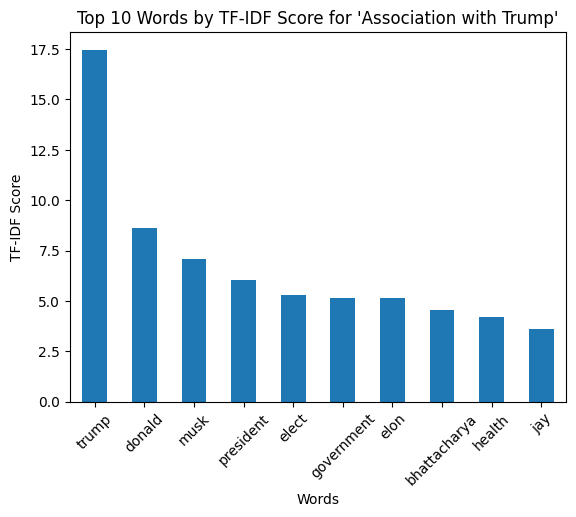

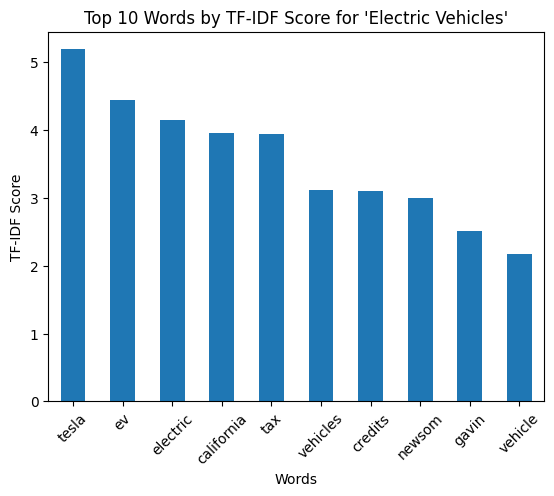

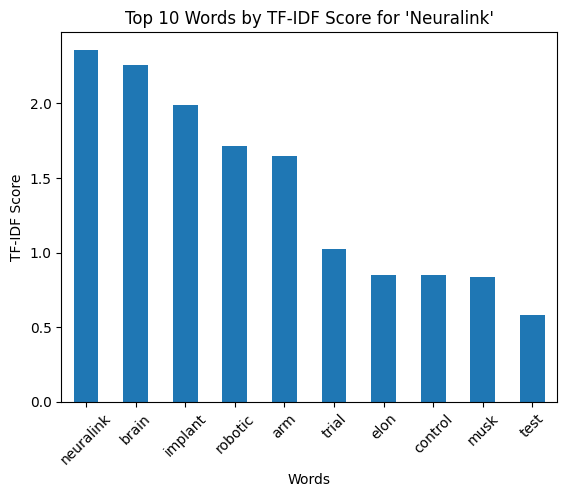

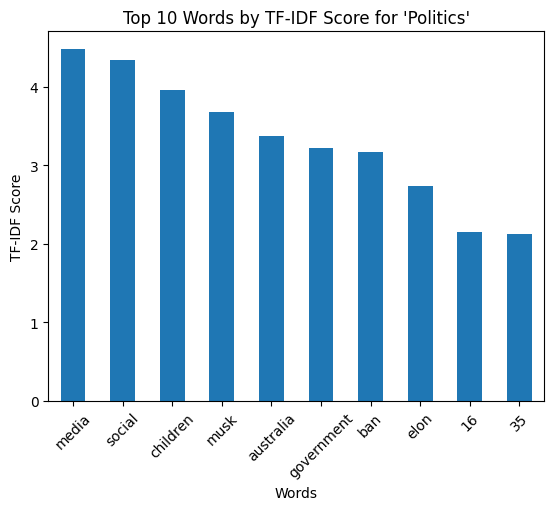

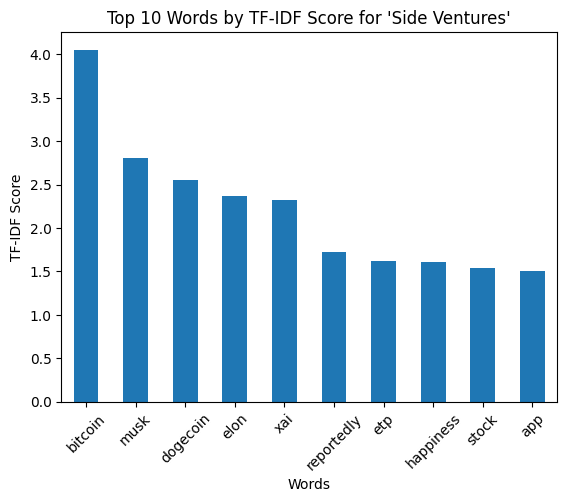

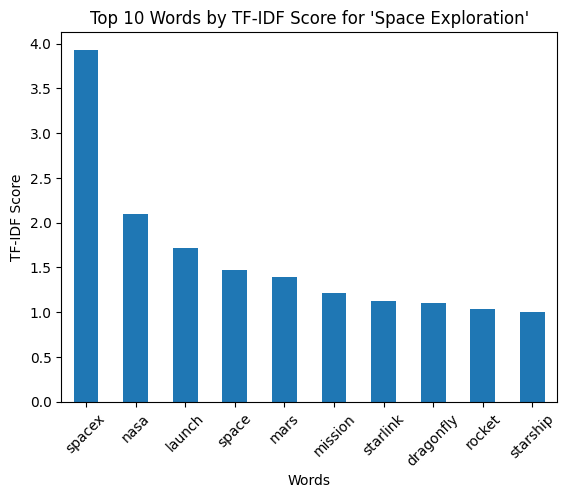

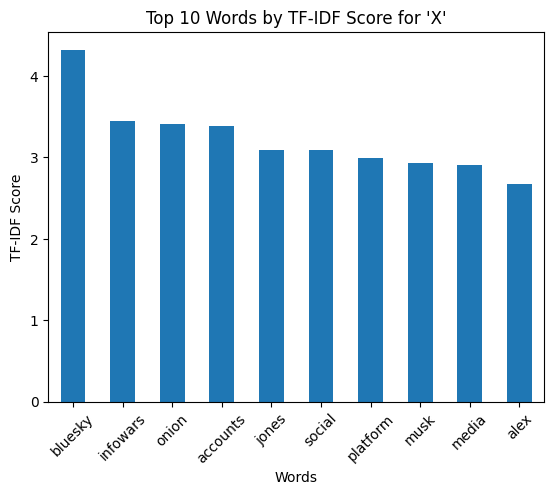

In [28]:
sums = tfidf_df.groupby(tfidf_df.index).sum()

category_scores = {
    category: sums.loc[category].nlargest(10)
    for category in sums.index
}

for category, scores in category_scores.items():
    scores.plot(kind='bar')
    plt.title(f"Top 10 Words by TF-IDF Score for '{category}'")
    plt.xlabel("Words")
    plt.ylabel("TF-IDF Score")
    plt.xticks(rotation=45)
    plt.show()
